# Simple Neural Network | MNIST

Implmentation of a configurable nerual network and trained on the MNIST digit classifer dataset. 
To test my understanding, only basic data and math libraries will be used.

### Packages and Dataset

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

train_data = pd.read_csv('./mnist/mnist_train.csv', header=None)
test_data = pd.read_csv('./mnist/mnist_test.csv', header=None)

The MNIST data set is in csv, with each row being one entry, 784 columns for each pixle on a 28 x 28 grid, the value representing brightness value from 0 to 1 black to white. 

In [2]:
# first column of the data is the digit
def parse_data(df):
    X = np.array(df.iloc[:,1:])
    Y = np.array(df.iloc[:,0])
    return X, Y

parse and load training and testing data and verfying shape

In [3]:
X, Y = parse_data(train_data)
X_te, Y_te = parse_data(test_data)
m,p = X.shape
X.shape

(60000, 784)

### Visualize Data Entries

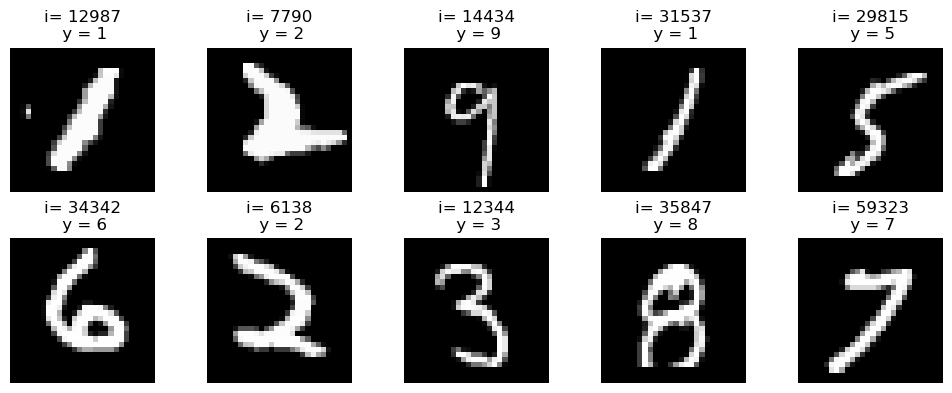

In [33]:
def plot_mnist(idxs, X_data, Y_data, rows):
    p_w, p_h = 2,2
    
    m = int(rows)
    n = int(len(idxs)/rows)
    fig, axes = plt.subplots(m, n, figsize=(p_w*n, p_h*m))
    for i, ax in enumerate(axes.flat):   
        ax.imshow(X_data[idxs[i],].reshape(28,28),cmap='gray', interpolation='nearest')
        ax.axis('off')
        ax.set_title(f"i= {idxs[i]}\n y = {Y_data[idxs[i]]}" )
    plt.tight_layout()
    plt.show()

plot_mnist(np.random.default_rng().integers(size=10, low=0, high=m-1), X, Y, 2)

# Definition & Notations
|Layer| Quantity | Definition | Size |
|:---:| :---: | :--- | :---: |
|**Input**||||
||$X = A^{[0]}$|Input| $m \times 784$|
|**Layer 1**||||
||$W^{[1]}$|Layer $1$ Weight | $784 \times 256$|
||$b^{[1]}$|Layer $2$ Bias |$1 \times 256$|
||$Z^{[1]}$|Layer $1$ Pre-activation| $m\times256$|
||$A^{[1]}$|Layer $1$ Activation| $m\times256$|
|**Layer 2**||||
||$W^{[2]}$|Layer $2$ Weight | $256 \times 128$|
||$b^{[2]}$|Layer $2$ Bias |$1 \times 128$|
||$Z^{[2]}$|Layer $2$ Pre-activation| $m\times128$|
||$A^{[2]}$|Layer $2$ Activation| $m\times128$|
|**Output Layer**||||
||$W^{[3]}$|Output Weight | $10 \times 128$|
||$b^{[3]}$|Output Bias |$1 \times 10$|
||$Z^{[3]}$|Output Logits| $m\times10$|
||$\hat{Y}$|Predicted Probabilities| $m\times10$|
||$Y$|Target| $m\times10$|

# Architecture
Each observation in the dataset is of dimension $28 \times 28$. The simplest representation of how we want to pass this data to the model would be to align all pixle values in one long vector of size $784$.
$$
X = (X_1, X_2, \cdots, X_m)^T , \hspace{.5cm}X_i\in \mathbb{R}^{1\times784}
$$

<small>we can also introduce more complicated 2-d relations to the model before passing it to the network, making it a CNN</small>

The prediction of our model should be a function conditioned on our training data $\hat{Y}_{tr} = f(X_{tr})$, which can be used to predict our test data $\hat{Y}_{te} = f(X_{te})$ to evaulate performance.

Since we are classifing the digits, their numerical values are meaningless, making the main metric of our model's performance -- the Loss Function -- will be Cross Entropy Loss, defined as
$$
L()
$$